In [1]:
pip install pmdarima

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [2]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.metrics import r2_score

In [3]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
data = pd.read_csv(io.StringIO(uploaded['US Soybeans Futures Historical Data.csv'].decode('utf-8')), index_col='Date', parse_dates=True)

Saving US Soybeans Futures Historical Data.csv to US Soybeans Futures Historical Data (2).csv


In [4]:
# Converting "Price", "Open", "High", "Low", "Vol." columns to float datatype
data['Price'] = data['Price'].str.replace(',', '').astype(float)
data['Open'] = data['Open'].str.replace(',', '').astype(float)
data['High'] = data['High'].str.replace(',', '').astype(float)
data['Low'] = data['Low'].str.replace(',', '').astype(float)
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000.

In [5]:
# fill missing values with mean of the column
data = data.fillna(data.mean())

# Check for null values in each column again
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64


<ipython-input-5-4e933ffb9d75>:2: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data = data.fillna(data.mean())


<Axes: xlabel='Date'>

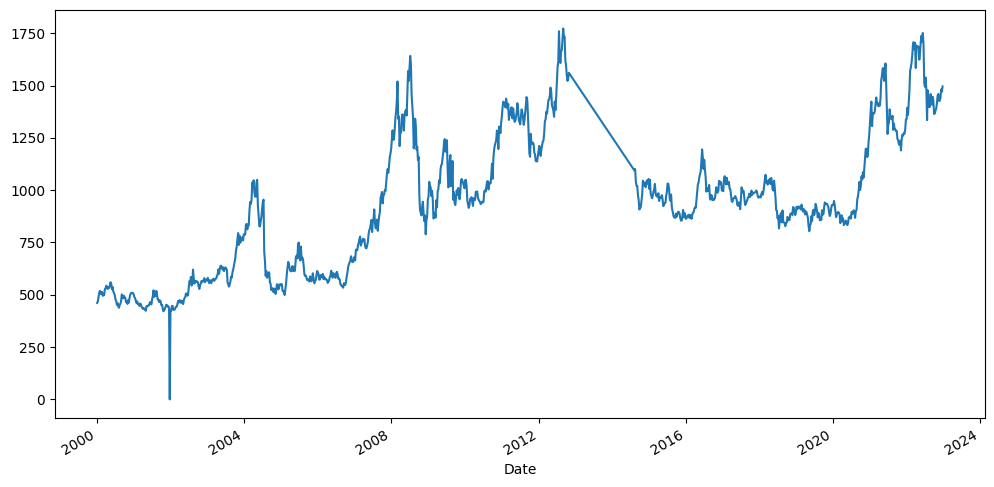

In [6]:
data["Open"].plot(figsize=(12,6))

In [7]:
# Dickey - Fuller Test
from statsmodels.tsa.stattools import adfuller

def ad_test(dataset):
  dftest = adfuller(dataset, autolag ='AIC')
  print("1. ADF: ", dftest[0])
  print("2. p-value: ", dftest[1])
  print("3. No. of lags: ", dftest[2])
  print("4. No. of observations used for ADF Regression and Critical Values Calculations: ", dftest[3])
  print("5. Critical Values: ")
  for key, val in dftest[4].items():
    print("\t", key, ",", val)

In [8]:
ad_test(data['Price'])

1. ADF:  -2.31363348533143
2. p-value:  0.16760859540306816
3. No. of lags:  12
4. No. of observations used for ADF Regression and Critical Values Calculations:  1072
5. Critical Values: 
	 1% , -3.4364647646486093
	 5% , -2.864239892228526
	 10% , -2.5682075189699822


In [9]:
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

In [10]:
stepwise_fit = auto_arima(data['Price'], trace=True, suppress_warnings=True)
stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=11128.629, Time=2.38 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=11146.970, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=11136.407, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=11138.789, Time=0.35 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=11145.569, Time=0.05 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=11126.674, Time=0.89 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=11124.685, Time=0.45 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=11126.676, Time=0.72 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=11129.350, Time=1.02 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=11128.431, Time=1.24 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=11123.269, Time=0.20 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=11137.507, Time=0.15 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=11125.262, Time=0.34 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=11125.263, Time=0.27 sec
 ARIMA(1,1,1)(0,0,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1085
Model:               SARIMAX(0, 1, 2)   Log Likelihood               -5558.635
Date:                Sun, 28 May 2023   AIC                          11123.269
Time:                        05:17:46   BIC                          11138.234
Sample:                             0   HQIC                         11128.935
                               - 1085                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0961      0.016     -6.191      0.000      -0.126      -0.066
ma.L2          0.1231      0.018      6.855      0.000       0.088       0.158
sigma2      1665.4719     28.829     57.770      0.000    1608.967    1721.977
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             17410.05
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               0.56   Skew:                             1.85
Prob(H) (two-sided):                  0.00   Kurtosis:                        22.28
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [11]:
# Drop the columns you don't need
data = data.drop(["Change %"], axis=1)

In [12]:
num_rows = data.shape[0]
print("Number of rows:", num_rows)

Number of rows: 1085


In [13]:
import statsmodels.api as sm

In [14]:
# Spllitting the dataset
print(data.shape)
train=data.iloc[:-7]
test=data.iloc[-7:]
print(train.shape, test.shape)

(1085, 5)
(1078, 5) (7, 5)


In [15]:
# Taining the model
model=sm.tsa.arima.ARIMA(train['Price'], order=(1,0,5))
model=model.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Price   No. Observations:                 1078
Model:                 ARIMA(1, 0, 5)   Log Likelihood               -5530.048
Date:                Sun, 28 May 2023   AIC                          11076.096
Time:                        05:17:48   BIC                          11115.959
Sample:                             0   HQIC                         11091.192
                               - 1078                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        928.3826    211.254      4.395      0.000     514.332    1342.433
ar.L1          0.9931      0.005    206.910      0.000       0.984       1.003
ma.L1         -0.0899      0.017     -5.322      0.000      -0.123      -0.057
ma.L2          0.1335      0.019      7.076      0.000       0.097       0.170
ma.L3         -0.0045      0.019     -0.233      0.816      -0.042       0.033
ma.L4          0.0131      0.022      0.603      0.546      -0.030       0.056
ma.L5         -0.0473      0.021     -2.293      0.022      -0.088      -0.007
sigma2      1665.5569     30.652     54.338      0.000    1605.480    1725.634
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):             17595.24
Prob(Q):                              0.88   Prob(JB):                         0.00
Heteroskedasticity (H):               0.56   Skew:                             1.96
Prob(H) (two-sided):                  0.00   Kurtosis:                        22.40
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
# Make predictions on the Test dataset
start = len(train)
end = len(train) + len(test)-1
pred = model.predict(start=start, end=end, type='levels')
print(pred)
pred.index = data.index[start:end+1]
print(pred)

1078    501.112058
1079    502.851539
1080    507.534861
1081    510.484840
1082    513.572539
1083    516.419403
1084    519.246729
Name: predicted_mean, dtype: float64
Date
2000-02-13    501.112058
2000-02-06    502.851539
2000-01-30    507.534861
2000-01-23    510.484840
2000-01-16    513.572539
2000-01-09    516.419403
2000-01-02    519.246729
Name: predicted_mean, dtype: float64


<Axes: xlabel='Date'>

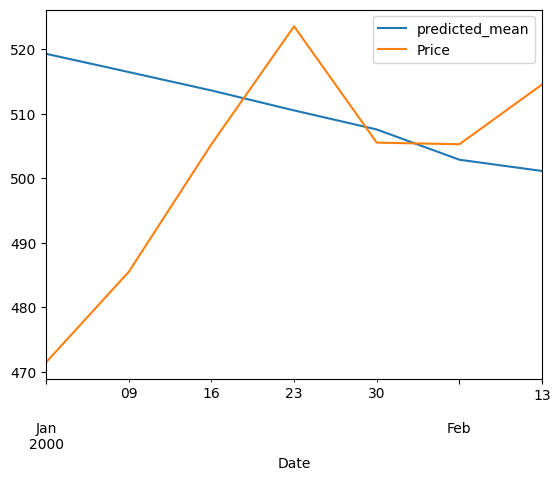

In [17]:
# Plotting the predicted values and the test set
pred.plot(legend=True)
test['Price'].plot(legend=True)

In [18]:
test['Price'].mean()

501.57142857142856

In [19]:
from sklearn.metrics import mean_squared_error
from math import sqrt

rmse=sqrt(mean_squared_error(test['Price'], pred))
print(rmse)

22.877152956496772
